## Цель работы
Построить модель, которая позволит классифицировать клиентов компании и определять, собираются ли они расторгнуть договор, на основе характеристик их профиля, поведения, платёжной активности.



## Задание
**1 часть - Анализ и визуализация**

•	Проверить наличие пропущенных значений в наборе данных о клиентах.

•	Проанализировать и показать основные статистические параметры набора данных (по аналогии как делали на семинаре).

•	Построить диаграмму распределения целевой переменной (Churn), отражающей факт оттока клиента. Сделать вывод о сбалансированности выборки.

•	Выбрать 5 признаков, вывести их названия и дать краткую интерпретацию (что, по вашему мнению, они означают в контексте и как могут влиять на целевую функцию – устно при защите).

•	Визуализировать взаимосвязи между 5 выбранными вами признаками и целевой переменной. Обосновать выбор признаков для анализа.

•	Построить boxplot для выбранных ранее признаков в связке с целевой переменной, оценить наличие выбросов и отметить особенности распределения для ушедших и лояльных клиентов.

•	Построить матрицу корреляций (помним про особенность категориальных признаков) между любым выбранным набором из 10 признаков. Проанализировать, какие признаки сильнее всего коррелируют с целевой переменной.

•	Визуализировать корреляцию между всеми имеющимися данными

•	Далее работать снова с набором из 5 признаков

---
**2 часть**

•	Построить и обучить модель логистической регрессии (c учётом предварительного масштабирования признаков)

•	Использовать комбинацию LogisticRegression и GridSearchCV для поиска лучшего значения гиперпараметра C. Обоснуйте выбор диапазона перебираемых значений (устно).

•	Вывести коэффициенты лучшей модели и визуализировать их с помощью столбчатой диаграммы.

•	Оценить качество модели: рассчитать accuracy, вывести матрицу ошибок в числовом и графическом виде, а также Classification Report (с кратким обоснованием результатов - устно).

•	Построить графики Precision-Recall и ROC-кривую (с пояснением для каждого, что показывают эти кривые в контексте задачи оттока).

•	Создать массив с произвольными значениями признаков для имитации нового события сети, проверить прогноз модели для этого события и оценить надежность предсказания.

•	Создать массив с произвольными значениями признаков, имитирующий анкету нового клиента. Проверить прогноз модели для этого события (уйдет клиент или нет) и вывести вероятность этого события.



# Задание 1

Каждая строка - это клиент компании, каждый столбец - характеристика клиента: поведение, тарифы, услуги, платежи.

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('dataset_lr2.csv')

## Несбалансированная выборка

In [6]:
len(df)

7043

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


- customerID-ID клиент
- gender- пол
- SeniorCitizen -является ли пенсионером (0/1)
- Partner - есть ли партнер (да нет)
- Dependents - есть ли зависящие от клиента люди иждивенцы (да нет)
- tenure - сколько месяцев пользуется услугами
- PhoneService - подключена ли телефонная связь
- MultipleLines - несколько телефонных линий
- InternetService - тип интернета (dsl, fiber optic, none)
- OnlineSecurity, TechSupport, StreamingTV, … - доп услуги
- Contract - тип контракта (Month-to-month, One year, Two year)
- PaperlessBilling - бумажная или электронная квитанция
- PaymentMethod - способ оплаты
- MonthlyCharges - ежемесячные расходы
- TotalCharges - общие расходы за все время
- Churn - факт ухода клиента (yes ушел, no остался)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


посмотрим на целевую переменную

In [12]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


выборка несбалансированная No сильно больше Yes

/tmp/ipython-input-2031787746.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn',data=df,palette='Set2')


<Axes: xlabel='Churn', ylabel='count'>

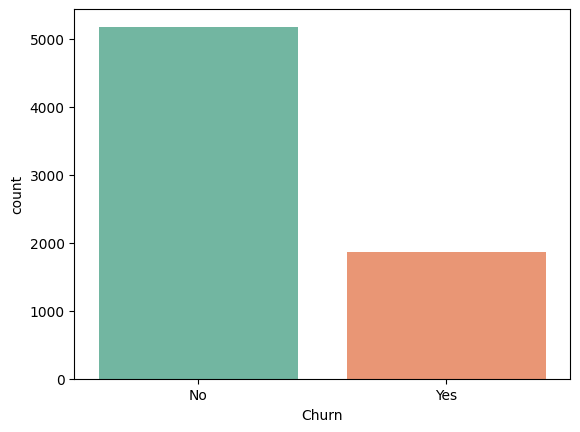

In [13]:
sns.countplot(x='Churn',data=df,palette='Set2')

модель должна научиться предсказывать переменную Churn -это классификация Yes No

Целевую переменную переведем в 0 и 1. Так будет лучше

In [14]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [15]:
df['Churn'].dtype

dtype('int64')

Для балансировки обучающей выборки случайным образом удалим часть строк класса 0 No, чтобы количество объектов обоих классов стало одинаковым

Случайная выборка используется для того, чтобы не искажать распределение признаков внутри класса и не удалять подряд схожие примеры.

In [16]:
df_no = df[df['Churn'] == 0]
df_yes = df[df['Churn'] == 1]
n_yes = len(df_yes)
df_no_sampled = df_no.sample(n=n_yes, random_state=42)
df_balanced = pd.concat([df_no_sampled, df_yes], axis=0)
df = df_balanced.sample(frac=1, random_state=42)


In [17]:
df['Churn'].value_counts()


,count
Churn,
0,1869
1,1869


Теперь модель будет одинаково уделять внимание обоим классам

исправляем то что TotalCharges тип object а не числовой

надо посмотреть сколько пустых строк, возможно там записан не 0, а пробел.
преобразовываем в число и проверяем

In [18]:
df['TotalCharges_num'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [19]:
df['TotalCharges_num'].isna().sum()

np.int64(5)

заменим NaN на 0

In [20]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [21]:
df['TotalCharges'].dtype

dtype('float64')

In [22]:
df.drop(columns=['TotalCharges_num'], inplace=True)

теперь тип float64 и столбец будет участвовать в графиках

## Сбалансированная выборка

In [23]:
df.tail(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
619,4059-IIEBK,Female,0,No,No,7,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),78.55,522.95,0
1159,4086-YQSNZ,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,80.40,224.05,1
3752,0412-UCCNP,Male,0,No,No,55,Yes,No,DSL,Yes,...,Yes,Yes,No,No,Two year,Yes,Electronic check,59.20,3175.85,0
4675,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,1
3823,9065-ZCPQX,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Bank transfer (automatic),78.85,5763.15,0
5955,7169-YWAMK,Male,0,Yes,Yes,72,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Bank transfer (automatic),68.40,4855.35,0
6396,2974-GGUXS,Female,1,Yes,No,36,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),91.95,3301.05,0
860,4795-UXVCJ,Male,0,No,No,26,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),19.80,457.30,0
6199,2856-NNASM,Male,1,No,No,43,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,89.55,3856.75,1
4978,4855-SNKMY,Female,0,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,44.10,44.10,1


In [24]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3949,4495-LHSSK,Female,0,No,Yes,18,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,57.65,992.70,0
555,5791-KAJFD,Female,0,Yes,Yes,56,Yes,Yes,DSL,Yes,...,Yes,No,No,Yes,One year,Yes,Bank transfer (automatic),68.75,3808.00,0
5982,3721-CNZHX,Male,0,No,No,15,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.80,304.60,0
6391,4000-VGMQP,Male,0,Yes,Yes,38,Yes,Yes,DSL,No,...,Yes,No,Yes,Yes,One year,No,Credit card (automatic),78.95,2862.55,0
5859,2194-IIQOF,Female,0,Yes,No,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),89.30,6388.65,0
5431,5995-WWKKG,Female,0,No,No,37,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Electronic check,19.80,695.05,0
6020,0020-JDNXP,Female,0,Yes,Yes,34,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Mailed check,61.25,1993.20,0
6409,3653-NCRDJ,Male,0,Yes,Yes,43,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.20,776.25,0
5638,5143-WMWOG,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,19.95,19.95,1
5499,4631-OACRM,Male,1,No,No,15,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,79.40,1156.10,1


данные успешно перемешались и классы сбалансированы. просто после объединения в один массив по очереди шли бы сначала Churn 0, а потом 1

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3738 entries, 3949 to 4978
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        3738 non-null   object 
 1   gender            3738 non-null   object 
 2   SeniorCitizen     3738 non-null   int64  
 3   Partner           3738 non-null   object 
 4   Dependents        3738 non-null   object 
 5   tenure            3738 non-null   int64  
 6   PhoneService      3738 non-null   object 
 7   MultipleLines     3738 non-null   object 
 8   InternetService   3738 non-null   object 
 9   OnlineSecurity    3738 non-null   object 
 10  OnlineBackup      3738 non-null   object 
 11  DeviceProtection  3738 non-null   object 
 12  TechSupport       3738 non-null   object 
 13  StreamingTV       3738 non-null   object 
 14  StreamingMovies   3738 non-null   object 
 15  Contract          3738 non-null   object 
 16  PaperlessBilling  3738 non-null   object 
 1

/tmp/ipython-input-2031787746.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn',data=df,palette='Set2')


<Axes: xlabel='Churn', ylabel='count'>

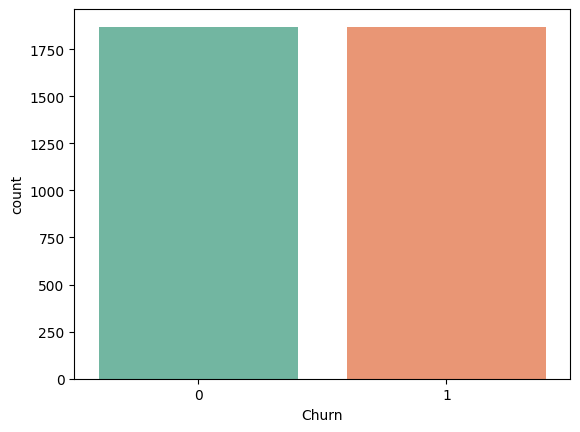

In [26]:
sns.countplot(x='Churn',data=df,palette='Set2')

Построим график пар - матрица диаграмм рассеяния , которая позволяет понять попарные отношения между различными переменными в наборе данных.

**для задач классификации можно в самом начале сразу строить такой график. Потому что здесь мы увидим в сжатом виде всю ту информацию, которую мы увидели на предыдущих графиках: распределение каждого из признаков, а также зависимость между признаками.**

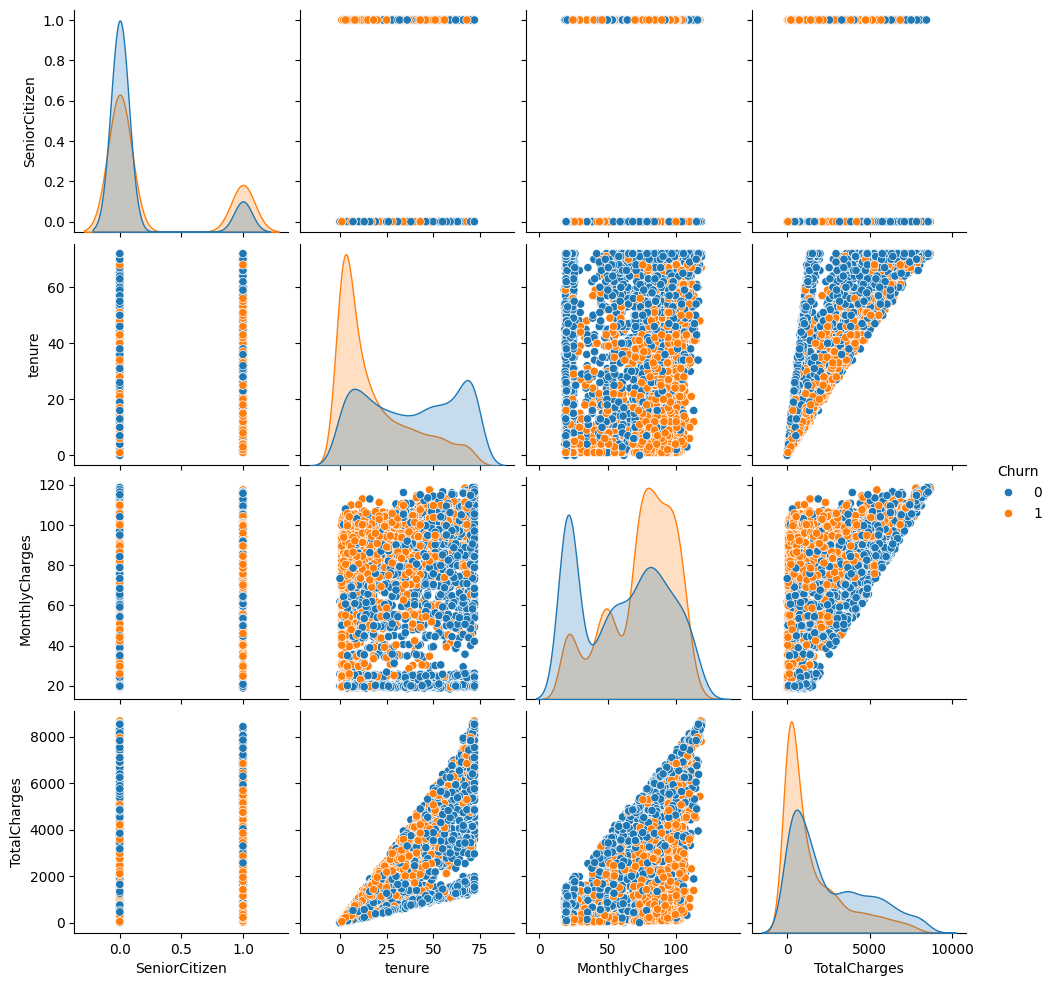

In [27]:
sns.pairplot(df,hue='Churn')

pairplot строит ВСЕ числовые признаки

просто посмотреть для качественных признаков

In [28]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

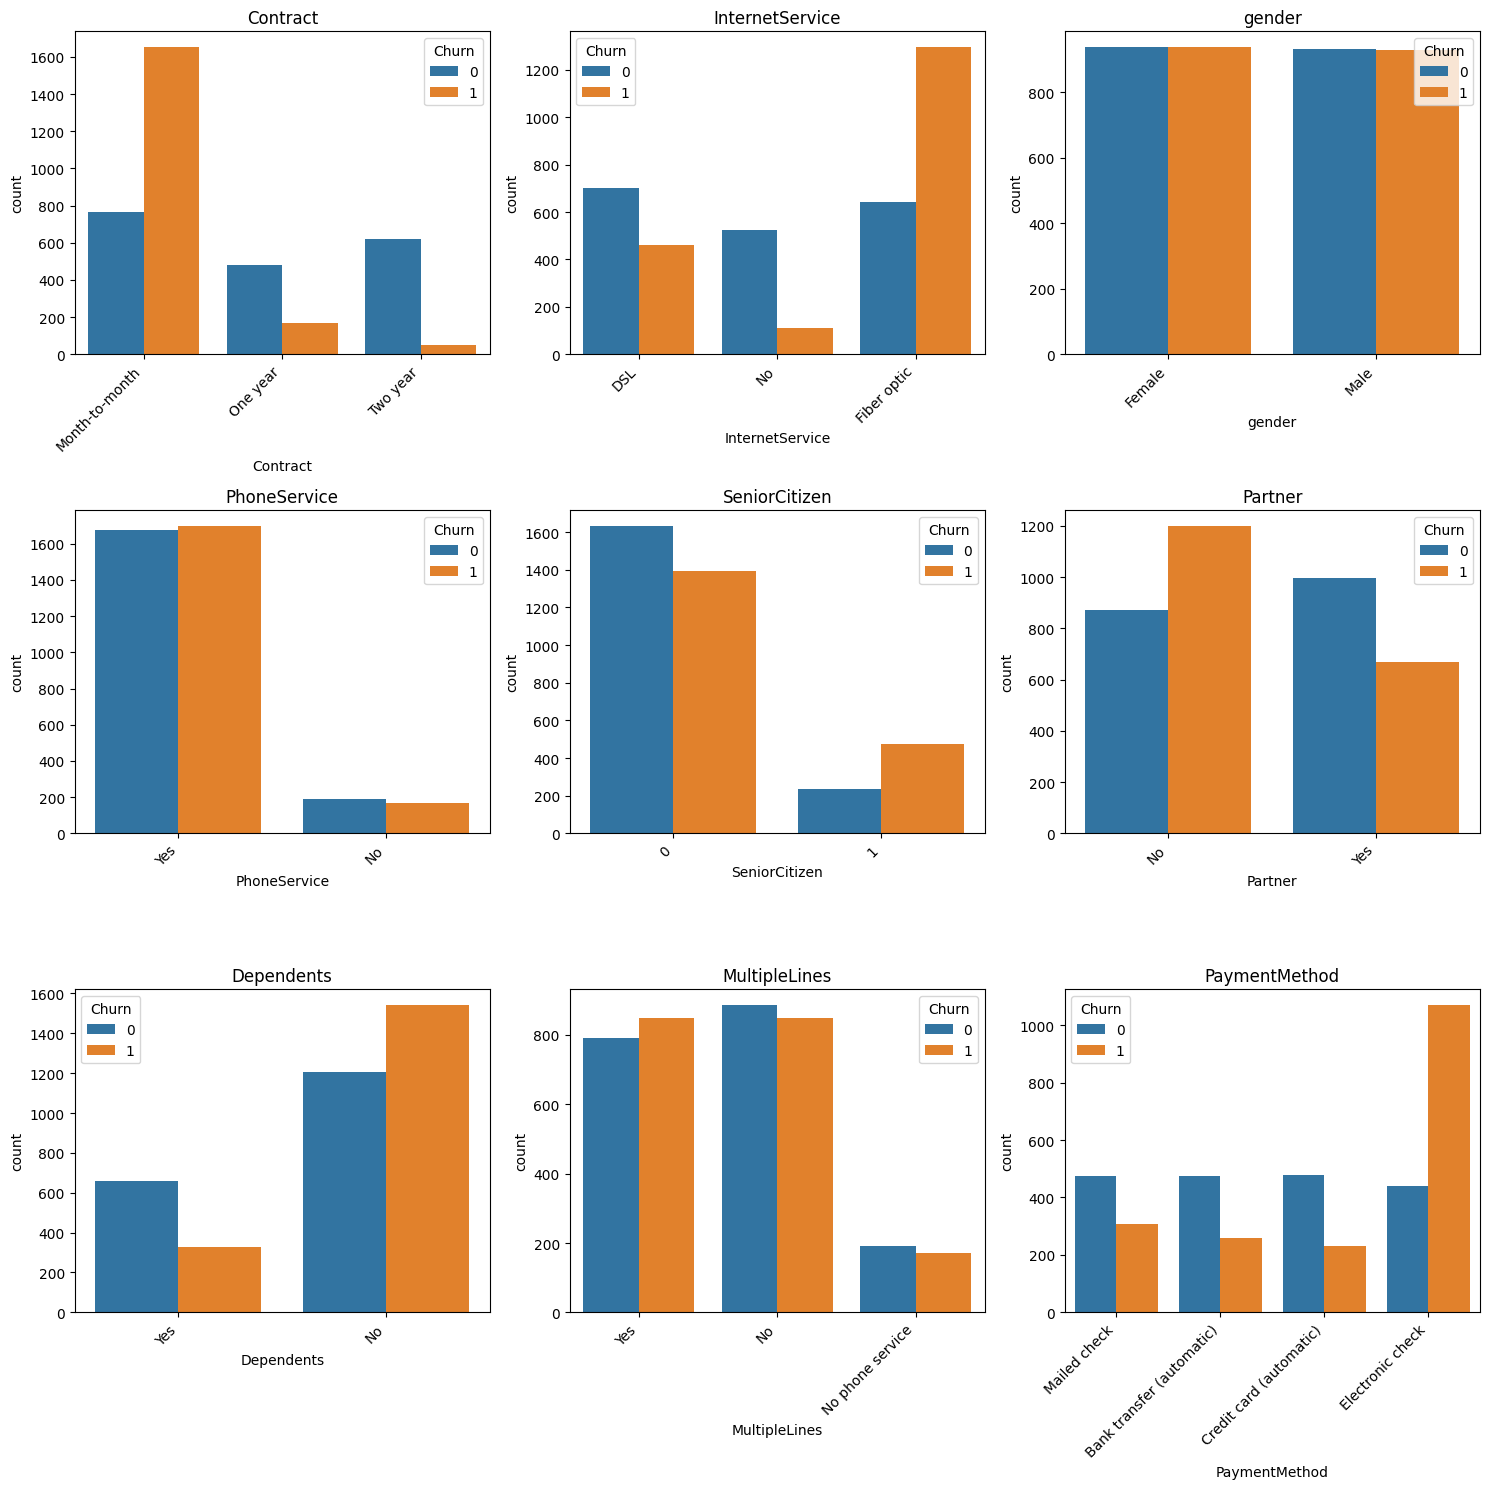

In [29]:
plt.figure(figsize=(15, 15))
for i, col in enumerate(['Contract', 'InternetService', 'gender', 'PhoneService', 'SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines', 'PaymentMethod']):
    plt.subplot(3,3,i+1)
    sns.countplot(x=col, hue='Churn', data=df)
    plt.xticks(rotation=45, ha='right')
    plt.title(col)
plt.tight_layout()
plt.show()

## выьерем наиболее важных 5 признаков
1) tenure
2) MonthlyCharges
3) TotalCharges
4) Contract
5) InternetService

по моему мнению они хорошо отражают экономическое поведение клиента и по ним можно получить почти полную картину о клиенте (признаки выбраны логически)

5 выбранных признаков

In [30]:
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService']
target = 'Churn'
df[features + [target]].head()

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,Churn
3949,18,57.65,992.70,Month-to-month,DSL,0
555,56,68.75,3808.00,One year,DSL,0
5982,15,19.80,304.60,One year,No,0
6391,38,78.95,2862.55,One year,DSL,0
5859,71,89.30,6388.65,Two year,DSL,0


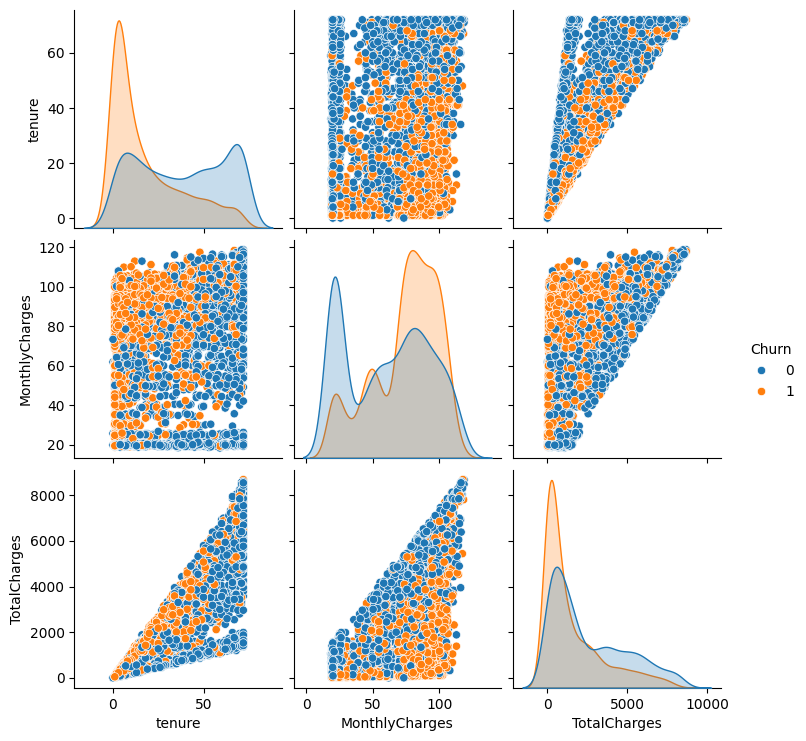

In [31]:
sns.pairplot(df[features + [target]], hue='Churn')
plt.show()

далее посмотрим распределение признаков с помощью boxplot

/tmp/ipython-input-2662144389.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')
/tmp/ipython-input-2662144389.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')
/tmp/ipython-input-2662144389.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='Set2')


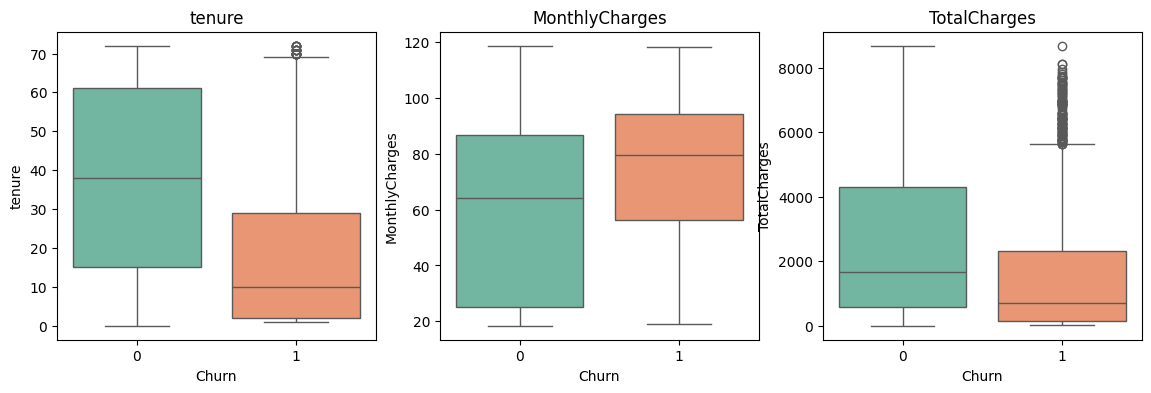

In [32]:
plt.figure(figsize=(14,4))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    plt.subplot(1,3,i+1)
    sns.boxplot(x='Churn', y=col, data=df, palette='Set2')
    plt.title(col)
plt.show()

Клиенты, которые ушли, в среднем пользовались услугами компании значительно меньше чем лояльные клиенты

Ушедшие клиенты в среднем платят больше ежемесячно чем лояльные клиенты

Лояльные клиенты имеют гораздо более высокую общую сумму платежей, чем ушедшие клиенты

Визуализация категориальных признаков (Contract, InternetService)

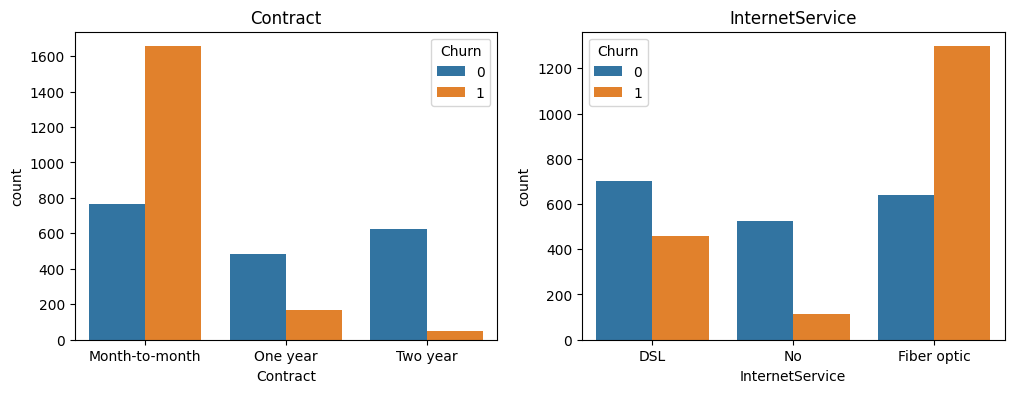

In [33]:
plt.figure(figsize=(12,4))
for i, col in enumerate(['Contract', 'InternetService']):
    plt.subplot(1,2,i+1)
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(col)
plt.show()

Тепловая карта heatmap для корреляции колонок.

хитмап работает только с числовыми типами данных, поэтому надо добавить выбор этих данных, потому что в противном случае не дает построить ValueError: could not convert string to float: '7590-VHVEG'

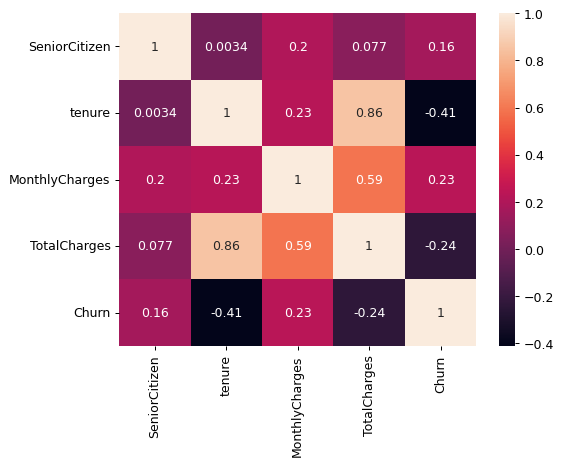

In [34]:
numeric_df = df.select_dtypes(include=['int64','float64'])
plt.figure(dpi=90)
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

Наиболее значимая связь с оттоком Churn это отрицательная корреляция с tenure (-0.41). это значит, что чем дольше клиент с компанией, тем меньше вероятность его ухода

слабая положительная корреляция с MonthlyCharges (0.23) более высокий месячный платеж может немного увеличивать риск ухода

TotalCharges второй по значимости после tenure -0.24

ради интереса построим хитмап и переведем категориальные признаки через dummy

In [35]:
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService', 'Churn']
df_corr = df[features]
df_corr = pd.get_dummies(df_corr, drop_first=True)

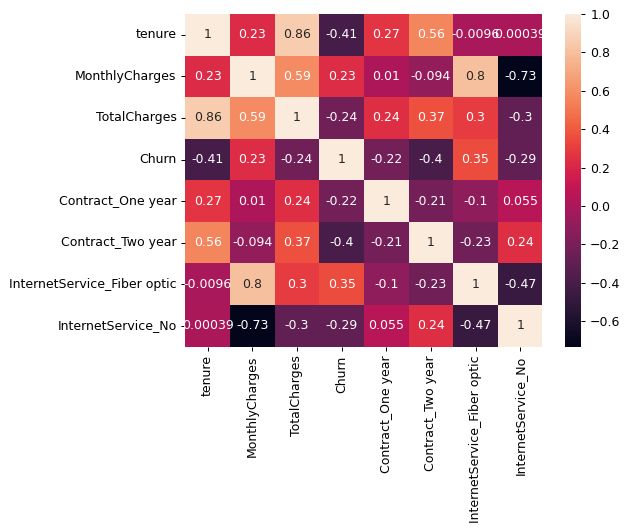

In [36]:
plt.figure(dpi=90)
sns.heatmap(df_corr.corr(), annot=True)
plt.show()


тут уже подробнее

- tenure=–0.41 - клиенты с большим сроком почти не уходят
- Contract_Two year=–0.40 -	двухлетний контракт сильно снижает отток
- InternetService_Fiber optic=+0.35	- пользователи оптоволокна чаще уходят

у total_charges cвязь -0.24 pначит клиенты много заплатили суммарно именно потому, что давно пользуются услугами и не уходят

в целом общий характер корреляций хорошо согласуется с наблюдаемыми бизнес-процессами, то есть клиенты уходят чаще при высоких расходах и меньшей привязанности к компании

**Однако если у нас небольшое количество признаков, то мы можем попробовать построить трехмерные графики.**

можно ради интереса посмотреть несколько графиков с этими признаками
'tenure', 'MonthlyCharges', 'TotalCharges'


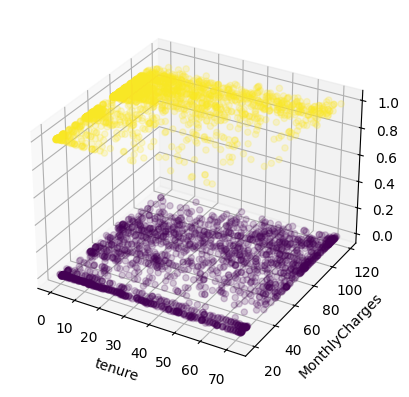

In [37]:
from mpl_toolkits.mplot3d import Axes3D
fig=plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(df['tenure'], df['MonthlyCharges'],df['Churn'],c=df['Churn'], alpha=0.2)

ax.set_xlabel('tenure')
ax.set_ylabel('MonthlyCharges')
plt.show()

нижняя плоскость Z=0 клиенты, которые НЕ ушли

верхняя плоскость Z=1 ушедшие клиенты

желтые точки находятся ближе к началу оси У - эт маленький стаж

часто вверху по оси У - большая плата за месяц

*клиенты, которые недолго пользовались услугой и платили больше, чаще уходят*

фиолетовые точки наоборот находятся дальше по оси X и распределены по У более равномерно

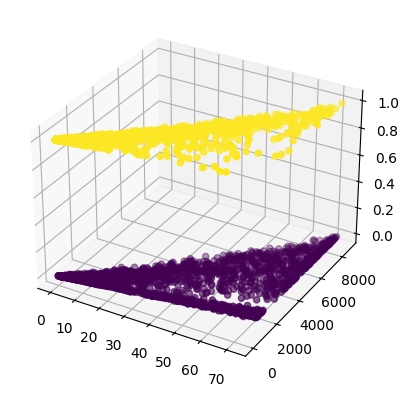

In [38]:
from mpl_toolkits.mplot3d import Axes3D
fig=plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(df['tenure'], df['TotalCharges'],df['Churn'],c=df['Churn'])

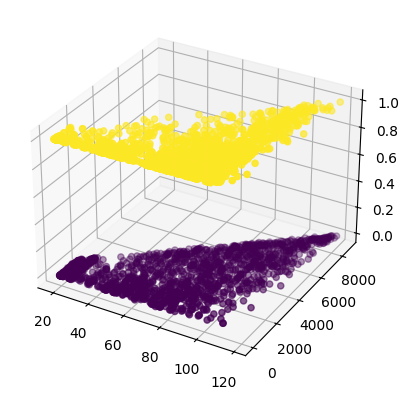

In [39]:
from mpl_toolkits.mplot3d import Axes3D
fig=plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(df['MonthlyCharges'], df['TotalCharges'],df['Churn'],c=df['Churn'])

# Задание 2

Логистическая регрессия — это алгоритм классификации машинного обучения, который используется для прогнозирования вероятности категориальной зависимой переменной. В логистической регрессии зависимая переменная — это бинарная переменная, содержащая данные, закодированные как 1 (да, успех и т.д.) или 0 (нет, неудача и т.д.). Другими словами, модель логистической регрессии предсказывает P(Y=1) как функцию от X.

Задача состоит в том, чтобы построить модель, с помощью которой мы могли бы взять какого-то нового клиента, получить для него значения признаков, и получить предсказание модели, уйдет ли клиент от компании или нет

### Разбиение на обучающую и тестовую выборки, а также масштабирование данных

создадим и обучим модель логистической регрессии с помощью Scikit-learn

Нужно создать фиктивные переменные Это переменные, имеющие только два значения — ноль и единицу

во первых потом scaler.fit_transform выдает could not convert string to float: '7601-WFVZV'

а также логистическая регрессия не умеет работать с «качественными» категориями,если их закодировать их простыми числами 0, 1, 2

Потому что модель подумает, что между ними есть числовой порядок (2>1>0). А для моих признаков это неправда, пожтому будет ухудшение качества

In [40]:
df['InternetService'].value_counts()

,count
InternetService,
Fiber optic,1938
DSL,1161
No,639


In [41]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,2421
Two year,670
One year,647


In [42]:
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService']
X = pd.get_dummies(df[features], drop_first=True)

теперь у нас есть полностью числовая матрица признаков Х



pd.get_dummies(..., drop_first=True)

Преобразует категориальные признаки (Contract, InternetService) в бинарные столбцы (0/1) — так называемые one-hot encoding

Параметр drop_first=True удаляет первый уровень каждой категориальной переменной, чтобы избежать мультиколлинеарности (лишней зависимости между признаками)

Например:
Было: Contract = ['Month-to-month', 'One year', 'Two year']

Стало (после drop_first=True):
Contract_One year, Contract_Two year

(а Month-to-month — базовый уровень, он не кодируется отдельно)

Числовые признаки (tenure, MonthlyCharges, TotalCharges) просто копируются без изменений

In [43]:
y = df['Churn']

Следующий шаг, как и ранее для линейной регрессии, мы можем выполнить масштабирование признаков. В частности, это позволит нам сравнивать коэффициенты между собой.

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [46]:
 # создаем объект scaler
 scaler= StandardScaler()

In [47]:
# масштабируем признаки
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

## Модель логистической регрессии

выполним обучение модели с применением поиска по сетке grid search для поиска параметров, а также выполним оценку работы модели

In [48]:
from sklearn.linear_model import LogisticRegression

In [49]:
from sklearn.model_selection import GridSearchCV

In [51]:
# В зависимости от предупреждений (warning), возможно Вам придётся
# поменять максимальное количество итераций или поэкспериментировать с другими объектами solver
# создаем модель
log_model = LogisticRegression(solver='liblinear',max_iter=1000)

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html


### Поиск лучших значений гиперпараметров с помощью GridSearch

нужно указать возможные значения гиперпараметров, которые будет перебирать gridSearchCV

Основные параметры - тип penalty и значение регуляризации C.


In [58]:
#print(np.logspace(0,3,4))

[   1.   10.  100. 1000.]


In [59]:
C = [0.01, 0.1, 1, 10, 100]

добавим эти списки в наш словарь


In [60]:
param_grid = {'C':C}

создаем модель GridModel, передаем базовую модель (logModel), Значение гиперпараметров paramGrid = paramGrid

In [61]:
grid_model = GridSearchCV(log_model,param_grid=param_grid)

In [62]:
grid_model.fit(scaled_X_train,y_train)

GridSearchCV(estimator=LogisticRegression(max_iter=1000, solver='liblinear'),
             param_grid={'C': [0.01, 0.1, 1, 10, 100]})

In [63]:
grid_model.best_params_

{'C': 1}

Подбор параметров считаем завершённым

In [64]:
best_model = grid_model.best_estimator_
best_model


LogisticRegression(C=1, max_iter=1000, solver='liblinear')

In [65]:
log_model = best_model

## Модель логистической регрессии


In [ ]:
#from sklearn.linear_model import LogisticRegressionCV , LogisticRegression

In [ ]:
 # выберем обычную, без кросс-валидации
 #log_model = LogisticRegression()

In [ ]:
 # обучаем модель
 #log_model.fit(scaled_X_train, y_train)

**В этой модели есть много полезных атрибутов. Прежде всего коэффициенты**

### Интерпретация коэффициентов

На что обратить внимание:

* Эти коэффициенты характеризуют *шансы (odds)*, их нельзя интепретировать напрямую, как мы это делали для линейной регрессии.
* Мы обучали модель на *масштабированной* версии данных
* Намного проще понять и интерпретировать связь между коэффициентами (между одним коэффициентом и другим), чем связь между этими коэффициентами и целевой переменной.



In [66]:
log_model.coef_

array([[-1.11026183, -0.1390245 ,  0.49120322, -0.35688364, -0.7022065 ,
         0.56683792, -0.44851633]])

In [67]:
X.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_One year',
       'Contract_Two year', 'InternetService_Fiber optic',
       'InternetService_No'],
      dtype='object')

коэффициенты

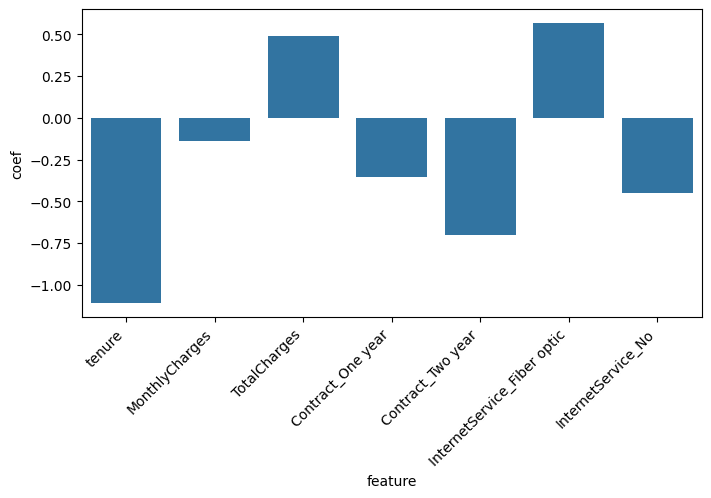

In [125]:
plt.figure(figsize=(8, 4))
sns.barplot(x='feature', y='coef', data=coef_df)
plt.xticks(rotation=45, ha='right')
plt.show()


Далее применим модель для тестовых данных

In [68]:
y_pred = log_model.predict(scaled_X_test)

In [69]:
y_pred

array([0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,

Кроме значений целевой переменной, мы также можем посмотреть вероятности. Для этого, кроме метода predict, есть еще два метода/ Predict log proba для логарифма вероятностей и predict proba для обычных вероятностей

In [70]:
y_pred_proba = log_model.predict_proba(scaled_X_train)
y_pred_proba

array([[0.33093585, 0.66906415],
       [0.79397657, 0.20602343],
       [0.17714343, 0.82285657],
       ...,
       [0.30648049, 0.69351951],
       [0.15060488, 0.84939512],
       [0.51705782, 0.48294218]])

получим для каждой точки список из двух вероятностей. Отдельно вероятность принадлежности к классу 0, и отдельно вероятность принадлежности к классу 1.

Cледующий шаг – это оценка работы модели. И поскольку для задач классификации у нас будет другой набор метрик, чем для задач регрессии, то нам нужно дополнительно изучить такие метрики, как **Accuracy, precision и recall, а также confusion matrix**. Метрики пригодятся нам не только для логистической регрессии, но и для других задач классификации.

https://habr.com/ru/companies/ods/articles/328372/

https://webiomed.ru/blog/osnovnye-metriki-zadach-klassifikatsii-v-mashinnom-obuchenii/

https://loginom.ru/blog/classification-quality

LogisticRegression

### Точность модели на задачах классификации

In [71]:
log_model.coef_

array([[-1.11026183, -0.1390245 ,  0.49120322, -0.35688364, -0.7022065 ,
         0.56683792, -0.44851633]])

In [72]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3949,4495-LHSSK,Female,0,No,Yes,18,Yes,Yes,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,57.65,992.70,0
555,5791-KAJFD,Female,0,Yes,Yes,56,Yes,Yes,DSL,Yes,...,Yes,No,No,Yes,One year,Yes,Bank transfer (automatic),68.75,3808.00,0
5982,3721-CNZHX,Male,0,No,No,15,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.80,304.60,0
6391,4000-VGMQP,Male,0,Yes,Yes,38,Yes,Yes,DSL,No,...,Yes,No,Yes,Yes,One year,No,Credit card (automatic),78.95,2862.55,0
5859,2194-IIQOF,Female,0,Yes,No,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),89.30,6388.65,0


вычислим метрики оценки модели для задач классификации.

In [73]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Выберем два метода и classification_report
1. accuracy_score (процент accuracy) -метрика сама по себе не может быть надежной в случае сильно несбалансированных классов
2. confusion matrix  (матрица ошибок)


In [74]:
y_test

,Churn
4296,1
414,0
1834,1
2887,1
761,1
...,...
1271,0
3696,1
5502,1
2197,0


In [75]:
# на тестовом наборе данных
y_pred = log_model.predict(scaled_X_test)

In [76]:
#y_pred # также набор значений 0 и 1

In [77]:
accuracy_score(y_test, y_pred)

0.7700534759358288

создадим матрицу ошибок, ConfusionMatrix, и передаем те же самые параметры, yTest и yPrediction

In [78]:
confusion_matrix(y_test, y_pred)

array([[283, 108],
       [ 64, 293]])

In [79]:
from sklearn.metrics import ConfusionMatrixDisplay

# В будущих версиях Scikit-Learn поменяется синтаксис для следующих методов:
#  - вместо plot_confusion_matrix нужно будет использовать ConfusionMatrixDisplay.from_estimator или ConfusionMatrixDisplay.from_predictions.
#  - вместо plot_precision_recall_curve нужно будет использовать PrecisionRecallDisplay.from_estimator и PrecisionRecallDisplay.from_predictions
#  - вместо plot_roc_curve нужно будет использовать RocCurveDisplay.from_estimator и RocCurveDisplay.from_predictions


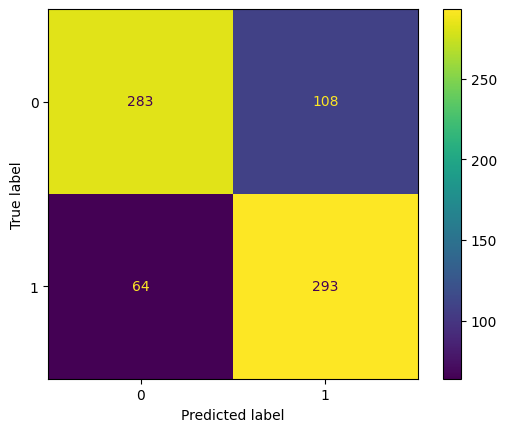

In [80]:
 # передаём модель и тестовый набор данных
 ConfusionMatrixDisplay.from_estimator(log_model,scaled_X_test,y_test)

здесь вэтой матрице ошибок:
- 283 (левый верхний) модель правильно предсказала, что клиент не уйдет
- 293(правый нижний) модель правильно предсказала уход
- 108 (правый верхний) модель ошиблась, предсказала, что клиент уйдет, но он остался
- 64 (левый нижний) модель ошиблась, предсказала, что клиент останется, но он ушел

Когда  будем смотреть другие модели классификации, то можем взять этот метод и передавать в него различные модели для одних и тех же тестовых данных.

нормализация по всем значениям показывает вклад каждого типа ошибок в общую работу модели

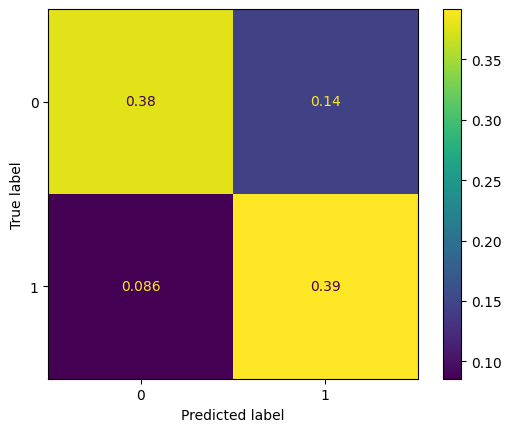

In [81]:
# Масштабированные данные: максимальное значение = 1
 # нормализация по всем значениям.
ConfusionMatrixDisplay.from_estimator(log_model,scaled_X_test,y_test, normalize='all')

нормализация по истинным значениям позволяет понять, какую долю объектов каждого класса модель распознает правильно

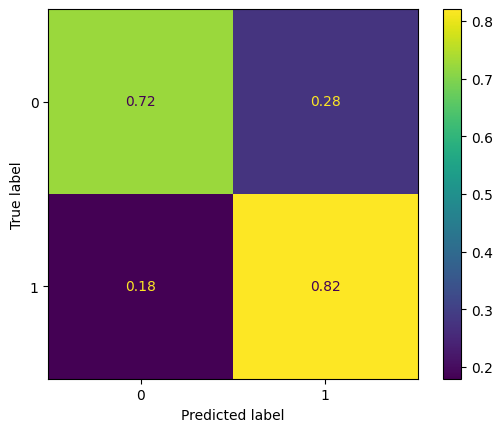

In [82]:
# Масштабированные данные: максимальное значение = 1
 # нормализация по истинным значениям.
ConfusionMatrixDisplay.from_estimator(log_model,scaled_X_test,y_test, normalize='true')

In [83]:
len(y_test)

748

Вычислим метрики Precision и Recall с помощью classification_report

In [84]:
classification_report(y_test, y_pred)

'              precision    recall  f1-score   support\n\n           0       0.82      0.72      0.77       391\n           1       0.73      0.82      0.77       357\n\n    accuracy                           0.77       748\n   macro avg       0.77      0.77      0.77       748\nweighted avg       0.78      0.77      0.77       748\n'

In [85]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.72      0.77       391
           1       0.73      0.82      0.77       357

    accuracy                           0.77       748
   macro avg       0.77      0.77      0.77       748
weighted avg       0.78      0.77      0.77       748



В этой таблице мы видим метрики precision, recall и f1 score, причем эти метрики вычислены отдельно для каждого класса.

f1-score — это гармоническое среднее между precision и recall.
support отражает количество объектов каждого класса в тестовой выборке (391 для класса 0 и 357 для класса 1)

После балансировки выборки классы представлены примерно одинаково, поэтому значения macro avg и weighted avg практически совпадают. модель работает равномерно для обоих классов, без смещения в сторону какого-то одного.

точность модели (accuracy) 0.77, а показатели f1-score для обоих классов одинаковы (0.77), что говорит о достаточно стабильном и сбалансированном качестве классификации

**получили общую картину с метриками**

In [86]:
from sklearn.metrics import precision_score, recall_score

In [87]:
# мы получаем общую метрику Precision, не отдельно для каждого из классов,
                                #а в целом для всей модели.
precision_score(y_test,y_pred)

0.7306733167082294

И по аналогии можно также вычислить метрику Recall.

In [88]:
 # Recall на уровне всех данных
 recall_score(y_test,y_pred)

0.8207282913165266

**В итоге видим, что модель показывает правильные результаты в интервале от 73 до 82% случаев по различным метрикам.**
в целом ок, лучше чем с несбалансированными данными


Графики ROC и Precision-Recall c помощью встроенных методов

In [89]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

**График ROC**

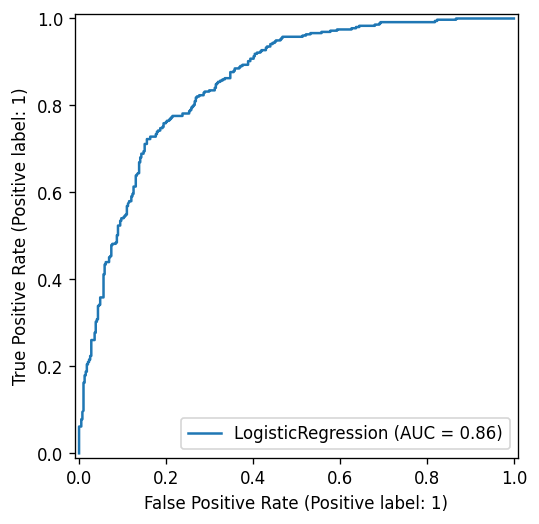

In [90]:
fig, ax=plt.subplots(dpi=120)
RocCurveDisplay.from_estimator(log_model, scaled_X_test, y_test, ax=ax)
# Передаем модель и тестовые данные

ROC — это график зависимости:
- True Positive Rate (Recall) на оси Y
- False Positive Rate на оси X
Он показывает, насколько хорошо модель различает классы при разных порогах классификации



AUC = Area Under Curve (площадь под ROC-кривой).

показывает высокую площадь под кривой (0.86), что говорит о хорошем качестве модели. модель в 86% случаев правильно отделяет клиентов, склонных к уходу, от лояльных клиентов

**График Precision-Recall**

Не такой популярный, как график ROC, но он тоже полезен. Он позволяет понять баланс между Precision и Recall.

Recall (полнота) - насколько хорошо модель находит всех уходящих клиентов

Precision (точность) - насколько модель права, когда говорит, что клиент уйдет


Чтобы recall стал максимальным(1), модель должна предсказать уход для всех клиентов, даже тех, кто реально не уйдет, т.е она ставит 1 везде

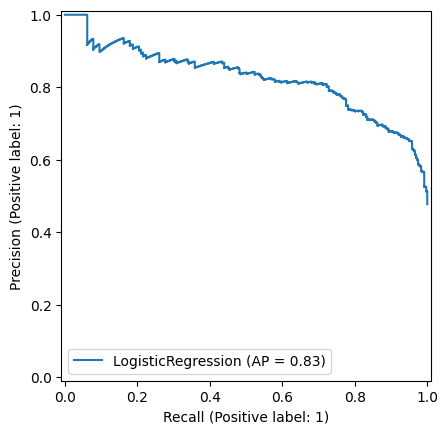

In [91]:
  # Передаем модель и тестовые данные
  PrecisionRecallDisplay.from_estimator(log_model, scaled_X_test, y_test)

AP (Average Precision) - площадь под кривой

В начале кривой модель работает почти безошибочно (precision = 1.0), но находит только небольшое число уходящих клиентов (низкий recall)

По мере увеличения recall до диапазона 0.7-0.8 модель сохраняет высокую точность (0.8), что говорит о хорошем качестве классификации

При достижении максимальной полноты точность закономерно снижается

Значение AP = 0.83 свидетельствует о сильной модели, хорошо различающей клиентов, склонных к уходу

In [92]:
log_model.predict_proba(scaled_X_test)

array([[0.57419827, 0.42580173],
       [0.38676193, 0.61323807],
       [0.30217209, 0.69782791],
       ...,
       [0.19758566, 0.80241434],
       [0.78785936, 0.21214064],
       [0.92723618, 0.07276382]])

In [93]:
# только первую строку для примера
log_model.predict_proba(scaled_X_test)[0]

array([0.57419827, 0.42580173])

In [94]:
y_test[0]

KeyError: 0

ИТОГ: истинное значение это класс 0

наша модель с вероятностью 94.8% предсказывает класс 0. И она предсказывает класс 1 с вероятностью 5.1%.

# Сохранение и загрузка модели

In [99]:
from joblib import dump, load

In [100]:
dump(log_model, 'Финальная модель.joblib')
dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [101]:
loaded_model = load('Финальная модель.joblib')
loaded_scaler = load('scaler.joblib')

In [102]:
log_model.coef_

array([[-1.11026183, -0.1390245 ,  0.49120322, -0.35688364, -0.7022065 ,
         0.56683792, -0.44851633]])

# Примеры и проверка модели

### Прогноз для нового клиента

In [103]:
new_client = pd.DataFrame({
    'tenure': [40],
    'MonthlyCharges': [55.0],
    'TotalCharges': [2100.0],
    'Contract': ['Two year'],
    'InternetService': ['DSL']
})

In [104]:
new_client_encoded = pd.get_dummies(new_client, drop_first=True)
new_client_encoded = new_client_encoded.reindex(columns=X.columns, fill_value=0)

In [105]:
new_client_scaled = loaded_scaler.transform(new_client_encoded)

In [106]:
pred = loaded_model.predict(new_client_scaled)
proba = loaded_model.predict_proba(new_client_scaled)

In [107]:
pred, proba

(array([0]), array([[0.63495556, 0.36504444]]))

модель предсказывает класс 0, то есть клиент не уйдет. вероятность ухода составляет 36.5%, а вероятность остаться — 63.5%

признаки
- длинный срок пользования tenure = 40
- суммарные платежи TotalCharges = 2100
- долговременный контракт Two year
- умеренная ежемесячная стоимость услу

### Прогноз для плохих данных

In [108]:
loaded_model = load('Финальная модель.joblib')
loaded_scaler = load('scaler.joblib')

In [109]:
new_event = pd.DataFrame({
    'tenure': [2],
    'MonthlyCharges': [95.0],
    'TotalCharges': [180.0],
    'Contract': ['Month-to-month'],
    'InternetService': ['Fiber optic']
})

In [110]:
new_event_enc = pd.get_dummies(new_event, drop_first=True)
new_event_enc = new_event_enc.reindex(columns=X.columns, fill_value=0)

In [111]:
new_event_scaled = loaded_scaler.transform(new_event_enc)

In [112]:
event_pred = loaded_model.predict(new_event_scaled)
event_proba = loaded_model.predict_proba(new_event_scaled)

In [113]:
event_pred, event_proba

(array([1]), array([[0.35855801, 0.64144199]]))

Модель предсказывает класс 1 — клиент уйдет
Вероятность ухода составляет 64%

- клиент только начал пользоваться услугами (tenure = 2)
- высокая ежемесячная стоимость
- контракт Month-to-month — самый нестабильный тип, клиент может уйти в любой момент
- Fiber optic — тариф, связанный с более высокой платежной нагрузкой

### Прогноз для реальных данных из датасета

возьмем ушедшего

9305-CDSKC Female 0 No No 8 Yes Yes Fiber optic No No Yes No Yes Yes Month-to-month Yes Electronic check 99.65 820.5 Yes

In [114]:
loaded_model = load('Финальная модель.joblib')
loaded_scaler = load('scaler.joblib')

In [115]:
new_event = pd.DataFrame({
    'tenure': [8],
    'MonthlyCharges': [99.65],
    'TotalCharges': [820.5],
    'Contract': ['Month-to-month'],
    'InternetService': ['Fiber optic']
})

In [116]:
new_event_enc = pd.get_dummies(new_event, drop_first=True)
new_event_enc = new_event_enc.reindex(columns=X.columns, fill_value=0)

In [117]:
new_event_scaled = loaded_scaler.transform(new_event_enc)

In [118]:
event_pred = loaded_model.predict(new_event_scaled)
event_proba = loaded_model.predict_proba(new_event_scaled)

In [119]:
event_pred, event_proba

(array([1]), array([[0.39511258, 0.60488742]]))

Модель предсказывает класс 1 - клиент уйдет. Вероятность ухода составляет 60,3%

Модель попала в реальные данные, клиент действительно ушел

# ГЛОБАЛЬНЫЙ ВЫВОД ПО МОДЕЛИ

После балансировки выборки (искусственного выравнивания классов Churn = 0 и Churn = 1) модель логистической регрессии значительно улучшила качество классификации. В отличие от первоначального обучения на несбалансированных данных, где модель была смещена в сторону предсказания класса 0, теперь она одинаково хорошо распознает оба класса

Accuracy = 0.77 — модель верно предсказывает исход для 77% клиентов

количество ошибок примерно одинаково распределено


**Модель логистической регрессии после балансировки данных показывает хорошее и стабильное качество классификации**